In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## UDR/IDR

The dataset used in this project contains daily USD/IDR exchange rate data obtained from Bank Indonesia (Source: https://www.bi.go.id/id/statistik/indikator/BI-Rate).
The data includes the buying rate, selling rate, and date from January 2015 to December 2024.

Since the raw dataset contains unnamed columns and an additional header row, preprocessing is required to rename columns and format the dataset properly.

In [4]:
# Read file
dataset_df = pd.read_excel("dataset/usdidr.xlsx", skiprows=3)

dataset_df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NO,Value,Sell,Buy,Date
1,1,1,16242.81,16081.19,12/31/2024 12:00:00 AM
2,2,1,16332.25,16169.75,12/30/2024 12:00:00 AM
3,3,1,16289.04,16126.96,12/27/2024 12:00:00 AM
4,4,1,16239.8,16078.2,12/24/2024 12:00:00 AM
...,...,...,...,...,...
2446,2446,1,12795,12667,1/8/2015 12:00:00 AM
2447,2447,1,12796,12668,1/7/2015 12:00:00 AM
2448,2448,1,12721,12595,1/6/2015 12:00:00 AM
2449,2449,1,12652,12526,1/5/2015 12:00:00 AM


## Data Preprocessing

Before conducting EDA, the following preprocessing steps are applied:
- Remove the extra header row
- Rename columns appropriately
- Convert the Date column to datetime format
- Sort the data according to date (ascending)

In [20]:
# Choose only date and sell
dataset_df = dataset_df[['Unnamed: 4', 'Unnamed: 2']].copy()
dataset_df = dataset_df.drop(index=0).reset_index(drop=True)

# Update column names
dataset_df.columns = ['period', 'idr_usd']

# Convert period into datetime
dataset_df['period'] = pd.to_datetime(dataset_df['period'], format="%m/%d/%Y %I:%M:%S %p")

# Ascending sort by date
dataset_df = dataset_df.sort_values('period').reset_index(drop=True)

dataset_df

,period,idr_usd
0,2015-01-02,12536
1,2015-01-05,12652
2,2015-01-06,12721
3,2015-01-07,12796
4,2015-01-08,12795
...,...,...
2445,2024-12-23,16351.35
2446,2024-12-24,16239.8
2447,2024-12-27,16289.04
2448,2024-12-30,16332.25


## Statistic Descriptive

The USD/IDR exchange rate exhibits <b>considerable variability</b>, with a standard deviation of approximately 890.99 and a trading range exceeding 4,300 points.

This wide range reflects <b>substantial fluctuations</b> in the foreign exchange market over the observed period.
Such variability suggests that exchange rate <b>volatility is not constant over time</b>, motivating the use of models that can capture time-varying volatility, such as <b>GARCH</b>.

In [22]:
# Ensure currency rate is a float
dataset_df['idr_usd'] = dataset_df['idr_usd'].astype(float)
# Get numeric cols only
numeric_cols = dataset_df.select_dtypes(include='number')

desc = numeric_cols.describe().T
# Skewness and kurtosis
desc['skewness'] = numeric_cols.skew()
desc['kurtosis'] = numeric_cols.kurtosis()

print(desc)

          count          mean         std      min       25%       50%  \
idr_usd  2450.0  14399.211641  890.989621  12506.0  13620.75  14328.29   

              75%       max  skewness  kurtosis  
idr_usd  14992.59  16824.71  0.351093 -0.638899  


No missing values found. Therefore, no need to do imputation.

In [23]:
# Missing values
print(dataset_df.isna().sum())

period     0
idr_usd    0
dtype: int64


##  USD/IDR Exchange Rate Trend (2015-2024)

The return series displays periods of relatively calm movements followed by periods of higher fluctuations. This pattern suggests the presence of volatility clustering, a common characteristic in financial time series.

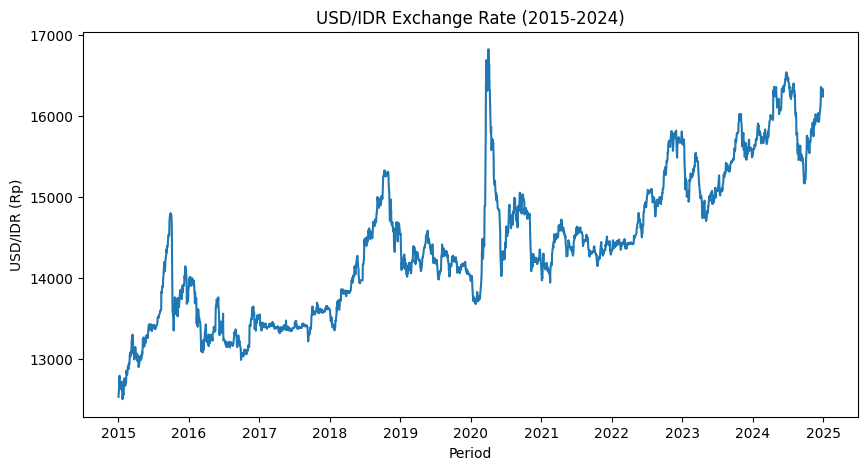

In [25]:
plt.figure(figsize=(10,5))
plt.plot(dataset_df['period'], dataset_df['idr_usd'])
plt.xlabel("Period")
plt.ylabel("USD/IDR (Rp)")
plt.title("USD/IDR Exchange Rate (2015-2024)", fontsize=12)
plt.show()

## Additional Features of Macroeconomic Indicators (Interest Rate & Inflation)

Sources:
- Inflasi - Bank Indonesia (https://www.bi.go.id/en/statistik/informasi-kurs/transaksi-bi/default.aspx)
- Interest Rate - Bank Indonesia (https://www.bi.go.id/en/statistik/indikator/bi-rate.aspx) and Federal Reserve Economic Data (https://fred.stlouisfed.org/series/IRSTCB01IDM156N)

In [28]:
#Read interest rate file
interest_df = pd.read_csv("dataset/interest_rate_df.csv")

interest_df.describe()

,interest_rate
count,120.000000
mean,5.208333
std,1.214986
min,3.500000
25%,4.250000
50%,5.250000
75%,6.000000
max,7.750000


In [29]:
#Read inflation file
inflation_df = pd.read_csv("dataset/inflation_df.csv")

inflation_df.describe()

,inflation_rate
count,120.000000
mean,3.374000
std,1.481175
min,1.320000
25%,2.502500
50%,3.190000
75%,3.842500
max,7.260000


In [30]:
#Download cleaned files (raw price)
dataset_df.to_csv("df.csv", index=False)

## Log-Returns

After transforming the price series into log returns, time series, histogram, and QQ plots are displayed to justify the use of GARCH.

In [2]:
# Read all files
df_returns = pd.read_csv("dataset/df_returns.csv")
inflation_df = pd.read_csv("dataset/inflation_df.csv")
interest_df = pd.read_csv("dataset/interest_rate_df.csv")

df_returns['period'] = pd.to_datetime(df_returns['period'])
inflation_df['period'] = pd.to_datetime(inflation_df['period'])
interest_df['period'] = pd.to_datetime(interest_df['period'])

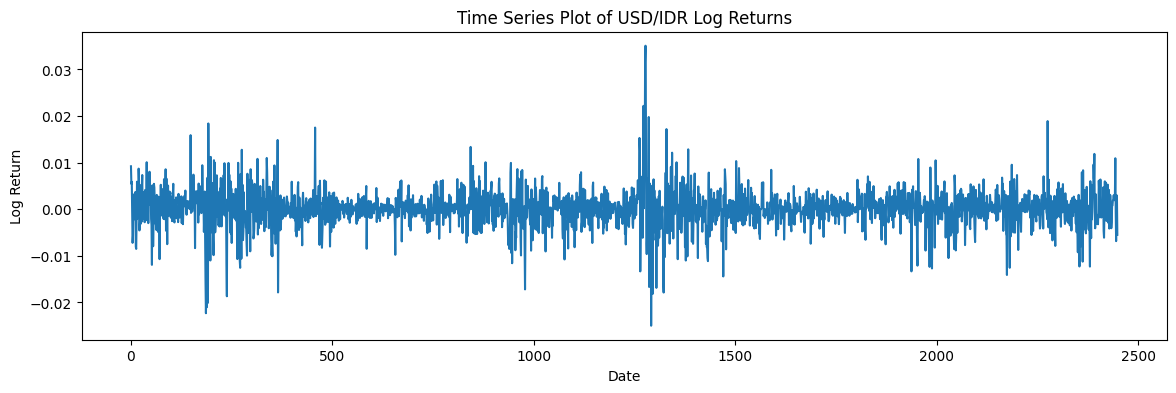

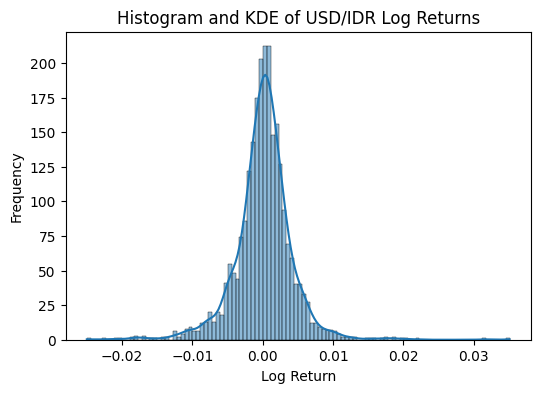

<Figure size 600x400 with 0 Axes>

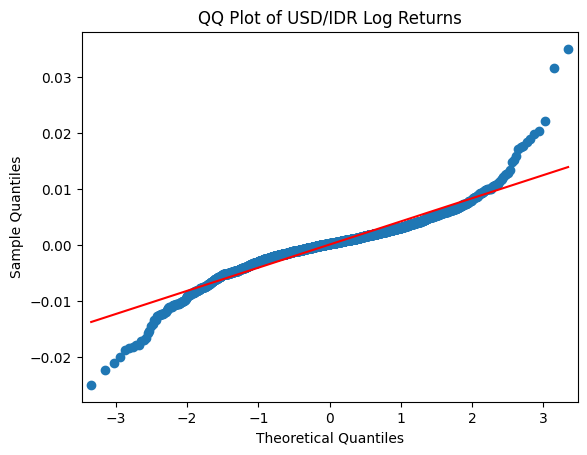

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

#Time series
plt.figure(figsize=(14, 4))
plt.plot(df_returns['idr_usd'])
plt.title('Time Series Plot of USD/IDR Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.show()

# Histogram + KDE
plt.figure(figsize=(6,4))
sns.histplot(df_returns['idr_usd'], kde=True)
plt.title('Histogram and KDE of USD/IDR Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

# QQ Plot
plt.figure(figsize=(6,4))
sm.qqplot(df_returns['idr_usd'], line='s')
plt.title('QQ Plot of USD/IDR Log Returns')
plt.show()

The return series shows clear volatility clustering, where periods of high volatility are followed by further high volatility.

Meanwhile, the histogram and QQ plots indicate that the variance is not constant over time (heteroskedasticity), which is a common characteristic of financial time series.

In addition, the distribution exhibits heavy tails and leptokurtosis, suggesting that extreme movements occur more frequently than predicted by a normal distribution.

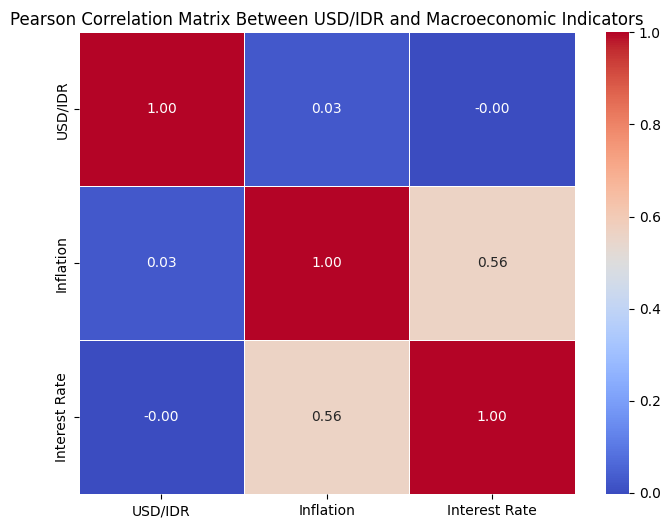

In [34]:
# Correlation Matrix

# Merge data
returns_macro = pd.merge(df_returns, inflation_df, on='period', how='outer')
returns_macro = pd.merge(returns_macro, interest_df, on='period', how='outer')

returns_macro[['inflation_rate', 'interest_rate']] = returns_macro[['inflation_rate', 'interest_rate']].ffill()
returns_macro = returns_macro.dropna().iloc[:, 2:]
returns_macro

col_names = {
    'idr_usd': 'USD/IDR',
    'inflation_rate': 'Inflation',
    'interest_rate': 'Interest Rate'
}

returns_macro = returns_macro.rename(columns=col_names)
corr_matrix = returns_macro.corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix Between USD/IDR and Macroeconomic Indicators')
plt.show()

A correlation matrix is used to examine the linear relationship between the exchange rate returns and the selected macroeconomic variables. This analysis helps identify whether the variables move together and provides an initial understanding of their potential influence on USD/IDR movements.

Additionally, the correlation matrix helps detect possible multicollinearity between input features before they are used in the modeling stage.

=============================================================================

The figure above shows that the linear correlation between the USD/IDR log returns and the selected macroeconomic variables is <b>relatively weak</b>. The correlation with inflation is approximately 0.03, while the correlation with interest rates is close to zero, indicating a negligible linear relationship.

Despite the weak linear correlation, these variables are still included as input features. In financial markets, relationships between macroeconomic indicators and exchange rates are often non-linear and dynamic.

Therefore, inflation and interest rates are incorporated into the LSTM model to allow the network to capture potential non-linear and long-term influences on exchange rate movements.